#RQ2: Hybrid Role Discovery
**Dissertation:** AI Approaches to Analysing Recruitment Demand: Machine learning insights from European Pharmaceutical Job Postings
**Author:** Kashmira Bhoir  
**Institution:** GISMA University of Applied Sciences  
**Date:** 21 June 2026  

## Research Question
What hybrid pharmaceutical roles emerge from hierarchical clustering
of European job postings, and how do their salary or location profiles differ?

## Key Findings
- Discovered Clusters   : 30  (silhouette score 0.542)
- Count of Hybrid roles detected  : 19 out of 30  (63% hybrid rate)
- Salary range           : €36,933 - €96,547  (€59,614 spread)
- Highest paying cluster: Medical Affairs Manager (€96,547, 826 jobs)
- Key discovery          : Medical Sales Liaison — 1,316 jobs, €54,568 avg
- Only non-hybrid cluster: 11 out of 30 - largest is Medical Sales Liaison — Account (772 jobs)

## Input
- `Europe_Pharma_Jobs_Cleaned.xlsx` - 9,520 rows, 16 columns

## Outcome
- Discovered 30 role clusters 19 classified as hybrid
- Salary and location profiles for each cluster
- 4 downloadable charts (dendrogram, UMAP, salary bar, bubble)

## Research Gap Addressed
- Puente Agueda (2024) — applied NLP techniques to gender analysis of European job postings, not role/salary clustering.
- Lukauskas (2023)     — NLP job-ad segmentation and clustering, specific to Lithuania.
- This study applies similar NLP/clustering techniques to discover data-driven hybrid roles across the entire European pharma job market — a different objective (role structure, not gender) and a different geography (EU-wide, not single-country).

Install and Import Libraries

In [12]:
!pip install umap-learn scikit-learn sentence-transformers pandas numpy matplotlib scipy -q

import pandas as pd
import numpy as np
import re
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
from IPython.display import display, HTML
from google.colab import files
import umap
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


Loading Cleaned Dataset

In [13]:
file_path = "/content/Europe_Pharma_Jobs_Cleaned.xlsx"
df_full   = pd.read_excel(file_path)
df_full.columns = df_full.columns.str.strip().str.lower().str.replace(" ", "_")
print(f"Loaded: {df_full.shape[0]:,} rows  |  {df_full.shape[1]} columns")
print(f"   Salary available : {df_full['salary_mid_eur'].notna().sum():,} rows")

Loaded: 9,520 rows  |  16 columns
   Salary available : 1,680 rows


Building Text Input and generating Embeddings

In [14]:
def build_text(row):
    title = str(row.get('job_title', ''))
    desc  = str(row.get('job_description', ''))[:300]
    loc   = str(row.get('country', ''))
    cat   = str(row.get('category', ''))
    return f"{title}. {cat}. {loc}. {desc}"

df_full['text_input'] = df_full.apply(build_text, axis=1)
print(f"Text input built for {len(df_full):,} rows")

print(f"\n Generating embeddings ({len(df_full):,} rows — takes ~6 mins on CPU)...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
emb_full = embedder.encode(
    df_full['text_input'].tolist(),
    batch_size        = 64,
    show_progress_bar = True
)
print(f"\n Embeddings shape: {emb_full.shape}")
print(f"   Each posting → {emb_full.shape[1]}-dimensional vector")

Text input built for 9,520 rows

 Generating embeddings (9,520 rows — takes ~6 mins on CPU)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/149 [00:00<?, ?it/s]


 Embeddings shape: (9520, 384)
   Each posting → 384-dimensional vector


Reduces Embedding Dimensions with UMAP

In [15]:
print("UMAP 384 → 50 dims...")
reducer_50 = umap.UMAP(
    n_components = 50,
    n_neighbors  = 30,
    min_dist     = 0.0,
    metric       = 'cosine',
    random_state = 42,
    n_jobs       = 1
)
emb_50 = reducer_50.fit_transform(emb_full)
print(f"UMAP 50-dim: {emb_50.shape}")

print("\n UMAP 50 → 2 dims (visualisation)...")
reducer_2d = umap.UMAP(
    n_components = 2,
    n_neighbors  = 30,
    min_dist     = 0.1,
    metric       = 'cosine',
    random_state = 42,
    n_jobs       = 1
)
emb_2d = reducer_2d.fit_transform(emb_50)
print(f" UMAP 2-dim: {emb_2d.shape}")

UMAP 384 → 50 dims...
UMAP 50-dim: (9520, 50)

 UMAP 50 → 2 dims (visualisation)...
 UMAP 2-dim: (9520, 2)


Finding Optimal Number of Clusters

In [16]:
print(" Finding optimal k (6–30)...")
sil_scores = {}

for k in range(6, 31):
    labels = AgglomerativeClustering(
        n_clusters=k, linkage='ward'
    ).fit_predict(emb_50)
    score  = silhouette_score(
        emb_50, labels, sample_size=2000, random_state=42
    )
    sil_scores[k] = score
    print(f"   k={k:2d}  silhouette={score:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n Best k = {best_k}  (silhouette = {sil_scores[best_k]:.4f})")

 Finding optimal k (6–30)...
   k= 6  silhouette=0.3615
   k= 7  silhouette=0.3664
   k= 8  silhouette=0.3683
   k= 9  silhouette=0.3806
   k=10  silhouette=0.3999
   k=11  silhouette=0.4235
   k=12  silhouette=0.4296
   k=13  silhouette=0.4612
   k=14  silhouette=0.4643
   k=15  silhouette=0.4745
   k=16  silhouette=0.4843
   k=17  silhouette=0.5000
   k=18  silhouette=0.5052
   k=19  silhouette=0.5142
   k=20  silhouette=0.5270
   k=21  silhouette=0.5321
   k=22  silhouette=0.5281
   k=23  silhouette=0.5334
   k=24  silhouette=0.5349
   k=25  silhouette=0.5374
   k=26  silhouette=0.5296
   k=27  silhouette=0.5375
   k=28  silhouette=0.5397
   k=29  silhouette=0.5397
   k=30  silhouette=0.5416

 Best k = 30  (silhouette = 0.5416)


Run Final Clustering with Optimal k

In [17]:
df_full['cluster'] = AgglomerativeClustering(
    n_clusters = best_k,
    linkage    = 'ward'
).fit_predict(emb_50)

print(f" Clustering complete: {best_k} clusters")
print(f"\n   Cluster sizes:")
cluster_sizes = df_full['cluster'].value_counts().sort_index()
for c, n in cluster_sizes.items():
    print(f"   Cluster {c:2d} : {n:,} jobs")

 Clustering complete: 30 clusters

   Cluster sizes:
   Cluster  0 : 67 jobs
   Cluster  1 : 1,316 jobs
   Cluster  2 : 831 jobs
   Cluster  3 : 867 jobs
   Cluster  4 : 772 jobs
   Cluster  5 : 1,057 jobs
   Cluster  6 : 463 jobs
   Cluster  7 : 276 jobs
   Cluster  8 : 468 jobs
   Cluster  9 : 826 jobs
   Cluster 10 : 24 jobs
   Cluster 11 : 40 jobs
   Cluster 12 : 788 jobs
   Cluster 13 : 32 jobs
   Cluster 14 : 25 jobs
   Cluster 15 : 33 jobs
   Cluster 16 : 37 jobs
   Cluster 17 : 32 jobs
   Cluster 18 : 67 jobs
   Cluster 19 : 121 jobs
   Cluster 20 : 48 jobs
   Cluster 21 : 564 jobs
   Cluster 22 : 22 jobs
   Cluster 23 : 16 jobs
   Cluster 24 : 51 jobs
   Cluster 25 : 601 jobs
   Cluster 26 : 12 jobs
   Cluster 27 : 12 jobs
   Cluster 28 : 12 jobs
   Cluster 29 : 40 jobs


Extract Defining Keywords per Cluster

In [18]:
print(" Extracting TF-IDF keywords:")
tfidf        = TfidfVectorizer(
    max_features = 5000,
    stop_words   = 'english',
    ngram_range  = (1, 2),
    min_df       = 3
)
tfidf_matrix  = tfidf.fit_transform(df_full['text_input'])
feat_names    = np.array(tfidf.get_feature_names_out())

cluster_keywords = {}
for c in range(best_k):
    mask          = (df_full['cluster'] == c).values
    ct            = tfidf_matrix[mask].mean(axis=0)
    top_idx       = np.asarray(ct).flatten().argsort()[::-1][:8]
    cluster_keywords[c] = feat_names[top_idx].tolist()

print(f" Keywords extracted for {best_k} clusters")
print(f"\n   Top keywords per cluster:")
for c, kws in cluster_keywords.items():
    print(f"   Cluster {c:2d}: {', '.join(kws[:5])}")

 Extracting TF-IDF keywords:
 Keywords extracted for 30 clusters

   Top keywords per cluster:
   Cluster  0: medical, consultancy, commercializes, commercializes medicines, regeneron
   Cluster  1: sales, medical, manager, territory, medical sales
   Cluster  2: marketing, manager, product, pharmaceutical, product manager
   Cluster  3: representative, sales, sales representative, medical sales, medical
   Cluster  4: account, account manager, manager, healthcare, sales
   Cluster  5: quality, engineer, assurance, quality assurance, qa
   Cluster  6: clinical, clinical research, research, cra, research associate
   Cluster  7: key account, key, account, account manager, manager
   Cluster  8: writer, medical writer, medical, senior medical, senior
   Cluster  9: medical, pharmacovigilance, medical affairs, information, medical information
   Cluster 10: cell therapy, cell, therapy account, account, therapy
   Cluster 11: communications agency, medical communications, account, communic

Generating Human-Readable Cluster Names

In [19]:
def base_name(cluster_id, keywords, df_cluster):
    kw = ' '.join(keywords).lower()
    if any(w in kw for w in ['data','statistics','statistical','analytics']):
        if any(w in kw for w in ['clinical','research','trial']):
            return 'Clinical Data Analyst'
        return 'Data Analyst'
    if any(w in kw for w in ['regulatory','submission']):
        return 'Regulatory Affairs Specialist'
    if any(w in kw for w in ['affairs','liaison','msl']):
        if any(w in kw for w in ['sales','commercial','marketing']):
            return 'Medical Sales Liaison'
        return 'Medical Affairs Manager'
    if any(w in kw for w in ['pharmacovigilance','safety','adverse']):
        return 'Pharmacovigilance Specialist'
    if any(w in kw for w in ['quality','gmp','validation','compliance']):
        if any(w in kw for w in ['manufacturing','production','process']):
            return 'QA Manufacturing Engineer'
        return 'Quality Assurance Specialist'
    if any(w in kw for w in ['clinical','trial','monitor','cra']):
        return 'Clinical Research Associate'
    if any(w in kw for w in ['sales','account','territory','commercial']):
        if any(w in kw for w in ['key','national','strategic']):
            return 'Key Account Manager'
        return 'Pharmaceutical Sales Rep'
    if any(w in kw for w in ['medical','writing','publication']):
        return 'Medical Writer'
    if any(w in kw for w in ['manufacturing','production','process']):
        return 'Manufacturing Engineer'
    if any(w in kw for w in ['marketing','brand','product','launch']):
        return 'Product Marketing Manager'
    size = len(df_cluster)
    if size < 50:  return 'Niche Pharma Specialist'
    if size < 150: return 'Specialist Pharma Role'
    return 'General Pharma Role'

def disambiguating_keyword(base_name_str, keywords):
    """Find a keyword belonging to this cluster that isn't already
    implied by its base name - that's the genuinely distinguishing word."""
    base_words = set(base_name_str.lower().split())
    for kw in keywords:
        if not set(kw.lower().split()) & base_words:
            return kw.title()
    return None

cluster_sizes_sorted = df_full['cluster'].value_counts().sort_values(ascending=False)
name_counts   = {}
cluster_names = {}

for c in cluster_sizes_sorted.index:
    mask   = (df_full['cluster'] == c).values
    bname  = base_name(c, cluster_keywords[c], df_full[mask])
    if bname not in name_counts:
        name_counts[bname] = 1
        cluster_names[c]   = bname
    else:
        distinguishing = disambiguating_keyword(bname, cluster_keywords[c])
        candidate = f"{bname} — {distinguishing}" if distinguishing else f"{bname} ({name_counts[bname]+2})"
        if candidate in cluster_names.values():
            candidate = f"{bname} ({name_counts[bname]+2})"
        name_counts[bname] += 1
        cluster_names[c]    = candidate

df_full['cluster_name'] = df_full['cluster'].map(cluster_names)

print(" Unique cluster names assigned:")
for c, name in sorted(cluster_names.items()):
    size = (df_full['cluster'] == c).sum()
    print(f"   Cluster {c:2d} ({size:,} jobs) → {name}")

 Unique cluster names assigned:
   Cluster  0 (67 jobs) → Clinical Research Associate — Medical
   Cluster  1 (1,316 jobs) → Pharmaceutical Sales Rep
   Cluster  2 (831 jobs) → Product Marketing Manager
   Cluster  3 (867 jobs) → Pharmaceutical Sales Rep — Representative
   Cluster  4 (772 jobs) → Pharmaceutical Sales Rep — Account
   Cluster  5 (1,057 jobs) → QA Manufacturing Engineer
   Cluster  6 (463 jobs) → Clinical Research Associate — Cra
   Cluster  7 (276 jobs) → Key Account Manager
   Cluster  8 (468 jobs) → Medical Writer
   Cluster  9 (826 jobs) → Medical Affairs Manager
   Cluster 10 (24 jobs) → Pharmaceutical Sales Rep — Cell Therapy
   Cluster 11 (40 jobs) → Pharmaceutical Sales Rep — Communications Agency
   Cluster 12 (788 jobs) → Clinical Research Associate
   Cluster 13 (32 jobs) → Medical Writer — Writing
   Cluster 14 (25 jobs) → Product Marketing Manager — Endo
   Cluster 15 (33 jobs) → Regulatory Affairs Specialist — Medical Writing
   Cluster 16 (37 jobs) → Nich

Building Cluster Salary and Location Profiles

In [20]:
cluster_profiles = []
for c in range(best_k):
    mask     = (df_full['cluster'] == c).values
    df_c     = df_full[mask]
    sal_rows = df_c[df_c['salary_mid_eur'].notna()]
    avg_sal  = sal_rows['salary_mid_eur'].mean() if len(sal_rows) > 0 else None
    top_loc  = df_c['country'].value_counts().index[0]
    top_3    = df_c['country'].value_counts().head(3).index.tolist()
    cat_mix  = df_c['category'].value_counts()
    top1_pct = cat_mix.iloc[0] / len(df_c) * 100
    is_hybrid = top1_pct < 70 and len(cat_mix) >= 2

    cluster_profiles.append({
        'Cluster'      : c,
        'Name'         : cluster_names[c],
        'Jobs'         : len(df_c),
        'Avg Salary €' : round(avg_sal, 0) if avg_sal else None,
        'Hybrid'       : ' Yes' if is_hybrid else '— No',
        'Top Location' : top_loc,
        'Top 3 Locations': ', '.join(top_3),
        'Top Keywords' : ', '.join(cluster_keywords[c][:4])
    })

df_profiles = pd.DataFrame(cluster_profiles).sort_values(
    'Jobs', ascending=False
).reset_index(drop=True)

print(f" Cluster profiles built")
print(f"\n   Hybrid roles : {(df_profiles['Hybrid'] == ' Yes').sum()}")
print(f"   Non-hybrid   : {(df_profiles['Hybrid'] == '— No').sum()}")
print(f"   Salary range : €{df_profiles['Avg Salary €'].min():,.0f} — "
      f"€{df_profiles['Avg Salary €'].max():,.0f}")

 Cluster profiles built

   Hybrid roles : 19
   Non-hybrid   : 11
   Salary range : €36,933 — €96,547


Display RQ2 Results Tables

In [23]:
hybrid_count = (df_profiles['Hybrid'] == ' Yes').sum()
sal_min      = df_profiles['Avg Salary €'].min()
sal_max      = df_profiles['Avg Salary €'].max()
sal_spread   = sal_max - sal_min

highest_paid_row = df_profiles.loc[df_profiles['Avg Salary €'].idxmax()]
most_common_row  = df_profiles.loc[df_profiles['Jobs'].idxmax()]
smallest_row     = df_profiles.loc[df_profiles['Jobs'].idxmin()]
hybrid_rows      = df_profiles[df_profiles['Hybrid'] == ' Yes']
key_hybrid_row   = hybrid_rows.loc[hybrid_rows['Jobs'].idxmax()] if len(hybrid_rows) > 0 else None
europe_count     = (df_profiles['Top Location'] == 'Europe (General)').sum()

print("TABLE 1: RQ2 KEY RESULTS SUMMARY")
print(f"  Total clusters discovered   : {best_k}")
print(f"  Hybrid role clusters        : {hybrid_count}")
print(f"  Non-hybrid clusters         : {best_k - hybrid_count}")
print(f"  Hybrid rate                 : {hybrid_count/best_k*100:.0f}%")
print(f"  Silhouette score (k={best_k}) : {sil_scores[best_k]:.3f}")
print(f"  Total job postings analysed : {len(df_full):,}")
print(f"  Salary range across clusters: €{sal_min:,.0f} – €{sal_max:,.0f}")
print(f"  Highest-paying cluster      : {highest_paid_row['Name']} (€{highest_paid_row['Avg Salary €']:,.0f})")
print(f"  Most common cluster         : {most_common_row['Name']} ({most_common_row['Jobs']:,} jobs)")
print(f"  Smallest cluster            : {smallest_row['Name']} ({smallest_row['Jobs']:,} jobs)")
if key_hybrid_row is not None:
    print(f"  Key hybrid discovery        : {key_hybrid_row['Name']} — {key_hybrid_row['Jobs']:,} jobs, €{key_hybrid_row['Avg Salary €']:,.0f} avg")

print("\nTABLE 2: FULL CLUSTER PROFILES")
print(df_profiles[['Name','Jobs','Avg Salary €','Hybrid','Top Location','Top Keywords']].to_string(index=False))

def top_categories_str(cluster_id, n=2):
    cats = df_full[df_full['cluster'] == cluster_id]['category'].value_counts().head(n)
    return ' + '.join(f"{name} ({count})" for name, count in cats.items())

print("\nTABLE 3: TOP 5 HYBRID ROLE DISCOVERIES (by job count)")
top5_hybrid = df_profiles[df_profiles['Hybrid'] == ' Yes'].sort_values('Jobs', ascending=False).head(5)
for _, row in top5_hybrid.iterrows():
    print(f"  {row['Name']:<35} {row['Jobs']:>5,} jobs   €{row['Avg Salary €']:>9,.0f}   "
          f"{top_categories_str(row['Cluster'])}")

print(f"\nTABLE 4: LOCATION PROFILES ({europe_count} of {best_k} clusters top-located in 'Europe (General)')")
print(df_profiles[['Name','Top 3 Locations']].to_string(index=False))

print("\nTABLE 5: RESEARCH GAP — PRIOR STUDIES VS THIS STUDY")
gap_data = {
   'Study': ['Puente Agueda (2024)', 'Lukauskas (2023)', 'Cedefop / JRC', 'This Study'],
'Geography': ['Europe (limited)', 'Lithuania only', 'NUTS-2 aggregates', 'Europe - 3 verified sources'],
'Method': ['NLP gender analysis of job postings', 'NLP job-ad segmentation', 'Labour market statistics', 'Agglomerative + Ward linkage'],
'Roles Discovered': ['N/A - not a role-discovery study', 'Fixed categories', 'Aggregate statistics', f'{best_k} data-driven hybrid roles'],
   }
print(pd.DataFrame(gap_data).to_string(index=False))

TABLE 1: RQ2 KEY RESULTS SUMMARY
  Total clusters discovered   : 30
  Hybrid role clusters        : 19
  Non-hybrid clusters         : 11
  Hybrid rate                 : 63%
  Silhouette score (k=30) : 0.542
  Total job postings analysed : 9,520
  Salary range across clusters: €36,933 – €96,547
  Highest-paying cluster      : Medical Affairs Manager (€96,547)
  Most common cluster         : Pharmaceutical Sales Rep (1,316 jobs)
  Smallest cluster            : Quality Assurance Specialist (12 jobs)
  Key hybrid discovery        : Pharmaceutical Sales Rep — 1,316 jobs, €54,568 avg

TABLE 2: FULL CLUSTER PROFILES
                                            Name  Jobs  Avg Salary € Hybrid     Top Location                                                           Top Keywords
                        Pharmaceutical Sales Rep  1316       54568.0    Yes   United Kingdom                                     sales, medical, manager, territory
                       QA Manufacturing Engineer  1057

Generate and Save RQ2 Visualisations

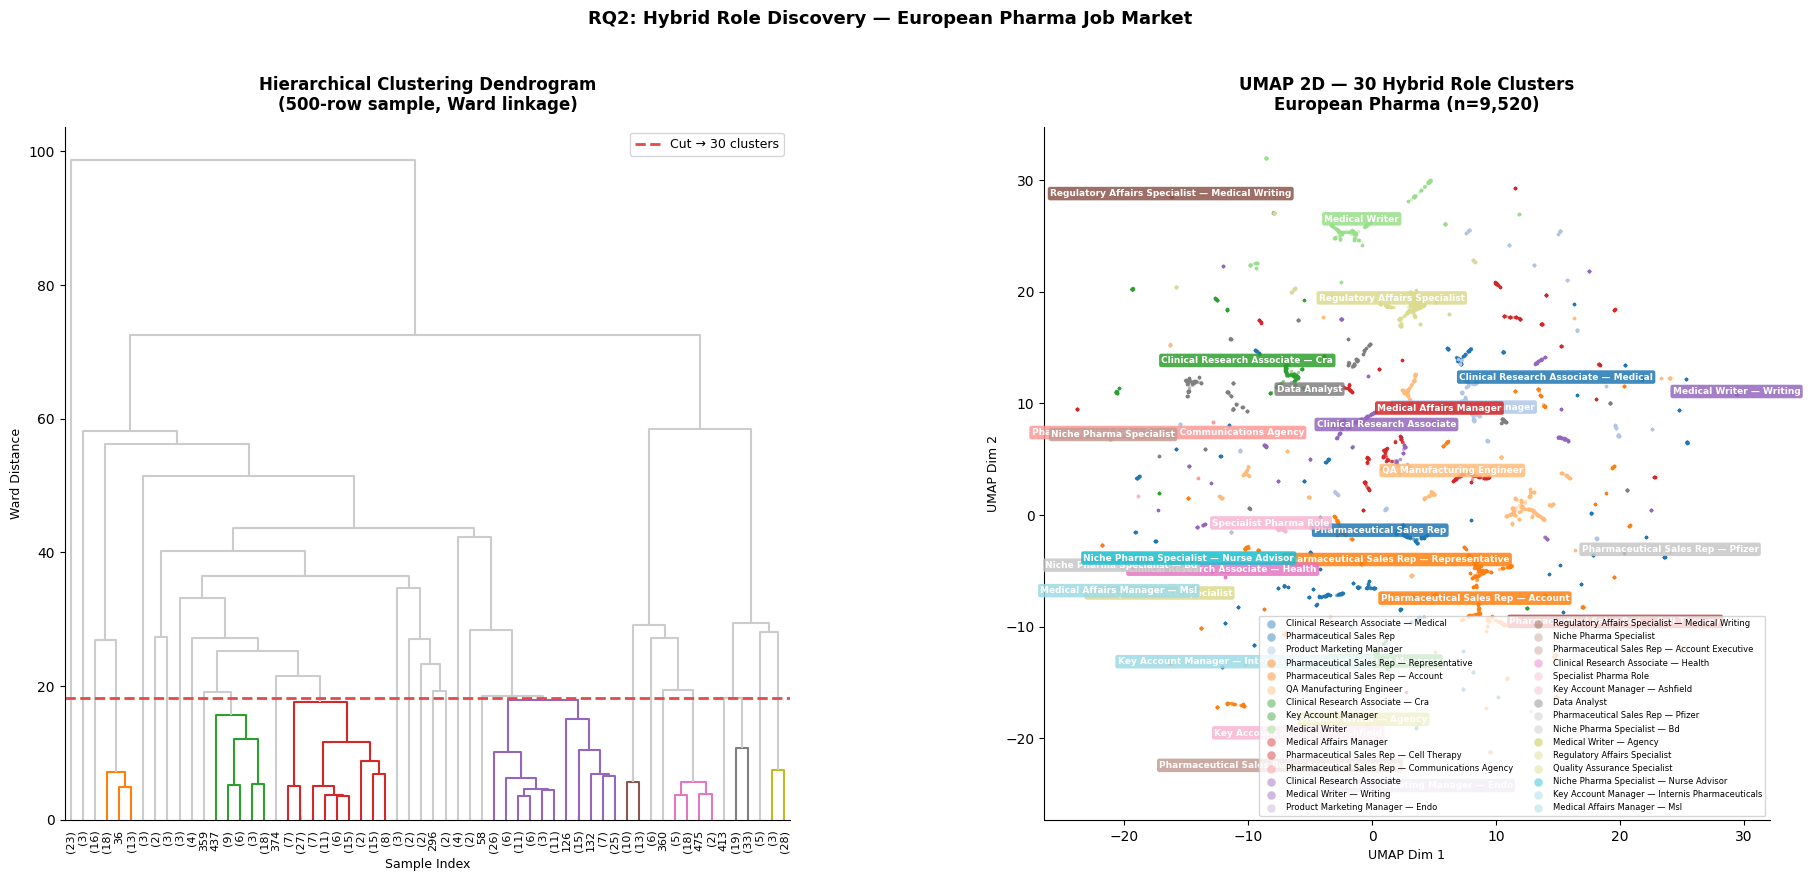

 Chart 1 saved → /content/rq2_dendrogram_umap.png


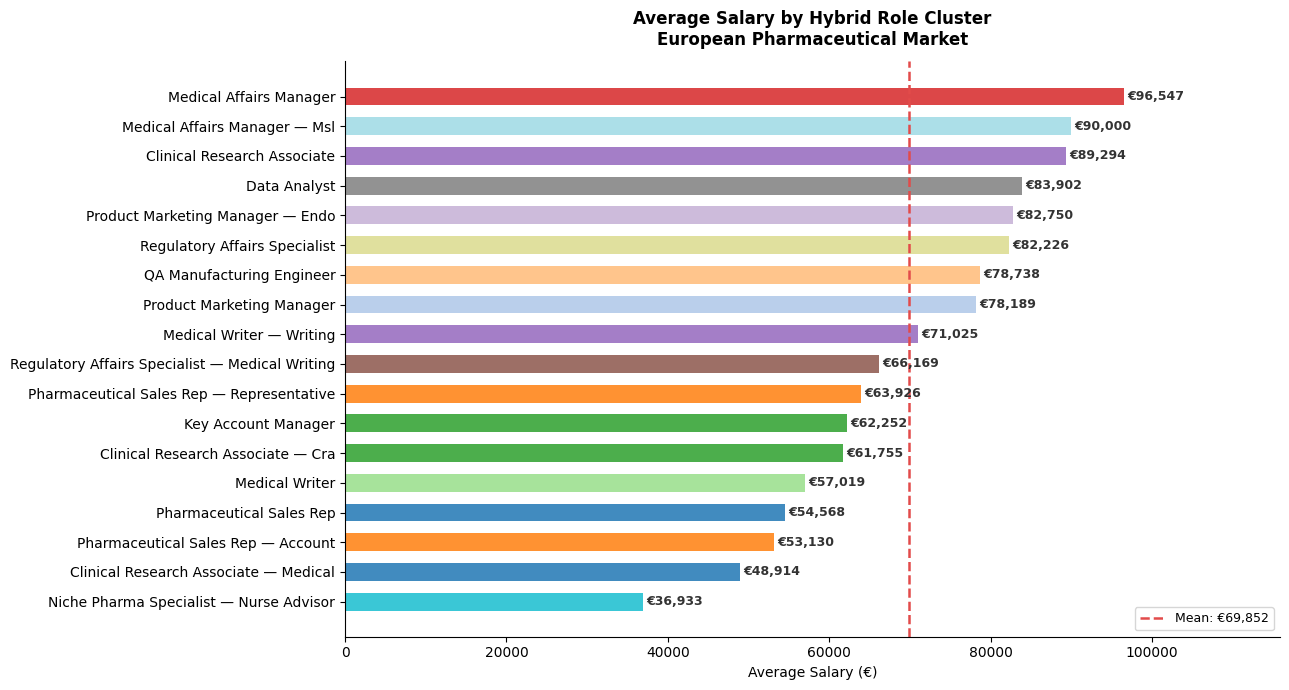

 Chart 2 saved → /content/rq2_salary_by_cluster.png


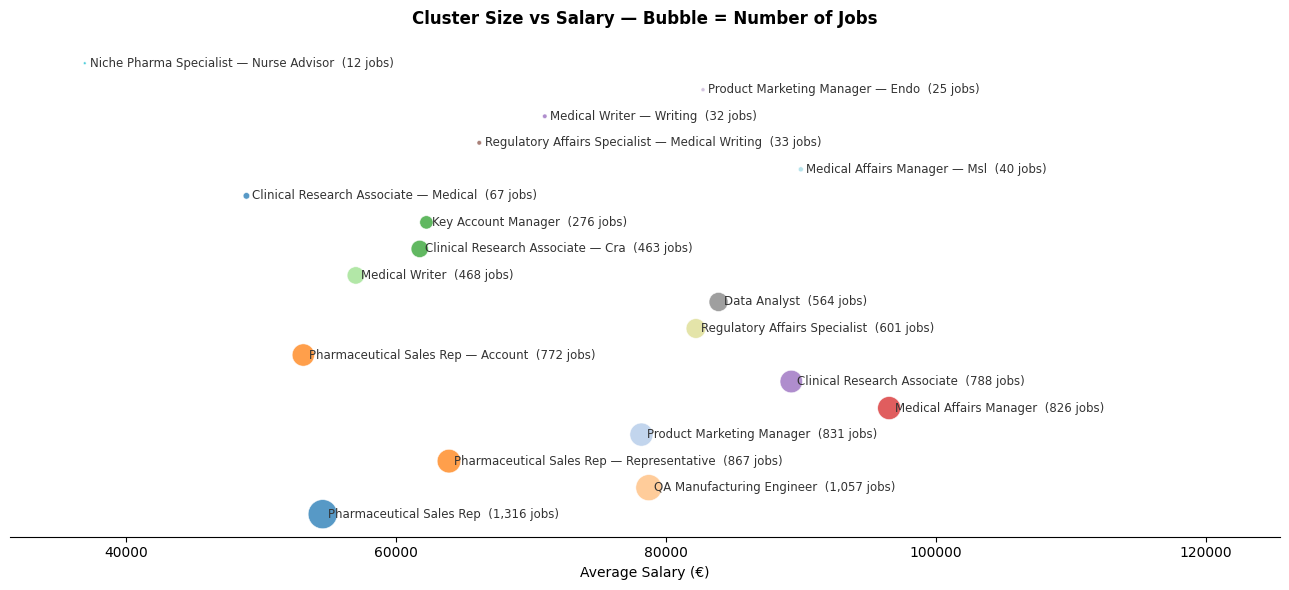

 Chart 3 saved → /content/rq2_bubble_chart.png


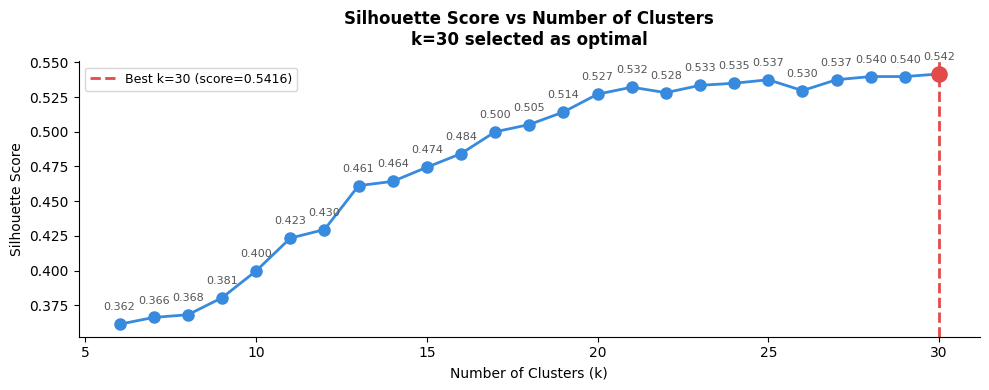

 Chart 4 saved → /content/rq2_silhouette.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 /content/rq2_dendrogram_umap.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

 /content/rq2_bubble_chart.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 /content/rq2_silhouette.png


In [22]:
colors_20 = plt.cm.tab20(np.linspace(0, 1, best_k))

sample_idx = np.linspace(0, len(emb_50) - 1, 500, dtype=int)
Z = linkage(emb_50[sample_idx], method='ward', metric='euclidean')

fig = plt.figure(figsize=(22, 9), facecolor='white')
gs  = GridSpec(1, 2, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('white')
dendrogram(Z, ax=ax1, truncate_mode='lastp', p=best_k*2,
           leaf_rotation=90, leaf_font_size=8, show_contracted=True,
           color_threshold=Z[-best_k+1, 2],
           above_threshold_color='#CCCCCC')
cut_h = Z[-best_k+1, 2]
ax1.axhline(y=cut_h, color='#E24B4A', lw=2, ls='--',
            label=f'Cut → {best_k} clusters')
ax1.set_title('Hierarchical Clustering Dendrogram\n'
              '(500-row sample, Ward linkage)',
              fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Sample Index', fontsize=9)
ax1.set_ylabel('Ward Distance', fontsize=9)
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('white')
for c in sorted(df_full['cluster'].unique()):
    mask = (df_full['cluster'] == c).values
    ax2.scatter(emb_2d[mask,0], emb_2d[mask,1],
                c=[colors_20[c]], label=cluster_names[c],
                alpha=0.45, s=6, linewidths=0)
    cx, cy = emb_2d[mask,0].mean(), emb_2d[mask,1].mean()
    ax2.annotate(cluster_names[c], (cx, cy),
                 fontsize=6.5, fontweight='bold', ha='center',
                 color='white',
                 bbox=dict(boxstyle='round,pad=0.25',
                           facecolor=colors_20[c],
                           alpha=0.85, edgecolor='none'))
ax2.set_title(f'UMAP 2D — {best_k} Hybrid Role Clusters\n'
              f'European Pharma (n={len(df_full):,})',
              fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('UMAP Dim 1', fontsize=9)
ax2.set_ylabel('UMAP Dim 2', fontsize=9)
ax2.legend(fontsize=6, loc='lower right',
           framealpha=0.8, markerscale=2.5, ncol=2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.suptitle('RQ2: Hybrid Role Discovery — European Pharma Job Market',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
chart1_path = '/content/rq2_dendrogram_umap.png'
plt.savefig(chart1_path, dpi=150, bbox_inches='tight', facecolor='white')
display(fig)
plt.close()
print(f" Chart 1 saved → {chart1_path}")

sal_df = df_profiles[df_profiles['Avg Salary €'].notna()].sort_values(
    'Avg Salary €', ascending=True).reset_index(drop=True)

fig2, ax3 = plt.subplots(figsize=(13, 7), facecolor='white')
ax3.set_facecolor('white')
bar_colors = [colors_20[int(r['Cluster'])] for _, r in sal_df.iterrows()]
bars = ax3.barh(sal_df['Name'], sal_df['Avg Salary €'],
                color=bar_colors, alpha=0.85, height=0.6)
for bar, val in zip(bars, sal_df['Avg Salary €']):
    ax3.text(bar.get_width()+400, bar.get_y()+bar.get_height()/2,
             f"€{val:,.0f}", va='center', fontsize=9,
             fontweight='bold', color='#333333')
mean_sal = sal_df['Avg Salary €'].mean()
ax3.axvline(x=mean_sal, color='#E24B4A', lw=1.8, ls='--',
            label=f'Mean: €{mean_sal:,.0f}')
ax3.legend(fontsize=9)
ax3.set_title('Average Salary by Hybrid Role Cluster\n'
              'European Pharmaceutical Market',
              fontsize=12, fontweight='bold', pad=12)
ax3.set_xlabel('Average Salary (€)', fontsize=10)
ax3.set_xlim(0, sal_df['Avg Salary €'].max() * 1.2)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
plt.tight_layout()
chart2_path = '/content/rq2_salary_by_cluster.png'
plt.savefig(chart2_path, dpi=150, bbox_inches='tight', facecolor='white')
display(fig2)
plt.close()
print(f" Chart 2 saved → {chart2_path}")

plot_df = df_profiles[df_profiles['Avg Salary €'].notna()].reset_index(
    drop=True)

fig3, ax4 = plt.subplots(figsize=(13, 6), facecolor='white')
ax4.set_facecolor('white')
ax4.scatter(
    plot_df['Avg Salary €'], range(len(plot_df)),
    s          = plot_df['Jobs'] / 3,
    c          = [colors_20[int(r['Cluster'])] for _, r in plot_df.iterrows()],
    alpha      = 0.75, linewidths=0.5, edgecolors='white'
)
for i, row in plot_df.iterrows():
    ax4.text(row['Avg Salary €']+400, i,
             f"{row['Name']}  ({row['Jobs']:,} jobs)",
             va='center', fontsize=8.5, color='#333333')
ax4.set_yticks([])
ax4.set_xlabel('Average Salary (€)', fontsize=10)
ax4.set_title('Cluster Size vs Salary — Bubble = Number of Jobs',
              fontsize=12, fontweight='bold', pad=12)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['left'].set_visible(False)
ax4.set_xlim(plot_df['Avg Salary €'].min()*0.85,
             plot_df['Avg Salary €'].max()*1.3)
plt.tight_layout()
chart3_path = '/content/rq2_bubble_chart.png'
plt.savefig(chart3_path, dpi=150, bbox_inches='tight', facecolor='white')
display(fig3)
plt.close()
print(f" Chart 3 saved → {chart3_path}")

fig4, ax5 = plt.subplots(figsize=(10, 4), facecolor='white')
ax5.set_facecolor('white')
ks     = list(sil_scores.keys())
scores = list(sil_scores.values())
ax5.plot(ks, scores, 'o-', color='#378ADD', lw=2, ms=8)
ax5.axvline(x=best_k, color='#E24B4A', lw=2, ls='--',
            label=f'Best k={best_k} (score={sil_scores[best_k]:.4f})')
ax5.scatter([best_k], [sil_scores[best_k]],
            color='#E24B4A', s=120, zorder=5)
for k, s in zip(ks, scores):
    ax5.annotate(f'{s:.3f}', (k, s),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=8, color='#555555')
ax5.set_xlabel('Number of Clusters (k)', fontsize=10)
ax5.set_ylabel('Silhouette Score', fontsize=10)
ax5.set_title(f'Silhouette Score vs Number of Clusters\n'
              f'k={best_k} selected as optimal',
              fontsize=12, fontweight='bold', pad=12)
ax5.legend(fontsize=9)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
plt.tight_layout()
chart4_path = '/content/rq2_silhouette.png'
plt.savefig(chart4_path, dpi=150, bbox_inches='tight', facecolor='white')
display(fig4)
plt.close()
print(f" Chart 4 saved → {chart4_path}")

print(f"\n Downloading all charts...")
for path in [chart1_path, chart2_path, chart3_path, chart4_path]:
    try:
        files.download(path)
        print(f" {path}")
    except Exception as e:
        print(f" {path} — {e}")